In [20]:
import numpy as np

In [1]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

z = np.array([
    [0],
    [1],
    [1],
    [0]
])

NameError: name 'np' is not defined

In [117]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

In [93]:
inputs, hiddens, outputs = 2, 2, 1
W1 = np.random.randn(inputs, hiddens) 
W2 = np.random.randn(hiddens, outputs) 
b1 = np.zeros(hiddens)
b2 = np.zeros(outputs)

In [97]:
W1 = np.array([[1, -1], [1, -1]], dtype=np.float32)
W2 = np.array([[1], [1], dtype=np.float32)
b1 = np.array([0.0, 2.0], dtype=np.float32)
b2 = np.array([-0.5], dtype=np.float32)
print(W1, W2, b1, b2)

[[ 0.5 -0.5]
 [ 0.5 -0.5]] [[0.5]
 [0.5]] [0. 2.] [-0.5]


In [98]:
def prediction(X, W1, W2, b1, b2):
    layer0 = X
    y1 = np.dot(X, W1) + b1
    layer1 = sigmoid(y1)
    y2 = np.dot(layer1, W2) + b2
    layer2 = sigmoid(y2)
    return layer0, layer1, layer2

In [99]:
y1 = np.dot(X, W1) + b1 
layer1 = sigmoid(y1)
y2 = np.dot(layer1, W2) + b2 

print(y1)
print(layer1)

[[0.  2. ]
 [0.5 1.5]
 [0.5 1.5]
 [1.  1. ]]
[[0.5 1. ]
 [1.  1. ]
 [1.  1. ]
 [1.  1. ]]


In [91]:
layer0, layer1, layer2 = prediction(X, W1, W2, b1, b2)
decision = layer2 >= 0.5
error = np.sum(np.abs(decision-z))
print(error)
print(layer2)

2
[[0.51672512]
 [0.9999481 ]
 [0.9999481 ]
 [0.51672512]]


### Loss = MSE

In [63]:
def fit(X, W1, W2, b1, b2, z, it_max=60000):
    lossArray = []
    learning_rate = 0.5
    for epoch in range(it_max):
        # prediction
        layer0, layer1, layer2 = prediction(X, W1, W2, b1, b2)
        z_2_hat = layer2
        
        # check break condition 
        decision = z_2_hat >= 0.5
        error = np.sum(np.abs(decision-z))
        loss = np.sum(np.abs(z_2_hat-z))
        lossArray.append(loss)
        #print(epoch, error, loss, z_2_hat.T)
        if error == 0:   break
        
        # Backpropagation
        layer2_error = layer2 - z
        layer2_delta = layer2_error * sigmoid_derivative(layer2)
        dW2 = np.dot(layer1.T, layer2_delta) / len(layer2_delta)
        db2 = np.sum(layer2_delta, axis=0) / len(layer2_delta)
        
        layer1_error = np.dot(layer2_delta, W2.T)
        layer1_delta = layer1_error * sigmoid_derivative(layer1)
        dW1 = np.dot(layer0.T, layer1_delta) / len(layer1_delta)
        db1 = np.sum(layer1_delta, axis=0) / len(layer1_delta)
        
        # Update
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1   

    return W1, W2, b1, b2, np.array(lossArray), decision

309 1 [[0.33982222 0.78830053 0.46563543 0.33124174]]
310 1 [[0.33840244 0.78915855 0.46994553 0.3285137 ]]
311 1 [[0.33693269 0.79001379 0.47437017 0.32575425]]
312 1 [[0.33541038 0.79086666 0.47890495 0.32296464]]
313 1 [[0.33383323 0.79171765 0.48354495 0.3201461 ]]
314 1 [[0.33219936 0.79256741 0.48828479 0.31729989]]
315 1 [[0.33050723 0.79341669 0.49311866 0.31442736]]
316 1 [[0.32875573 0.79426633 0.49804036 0.31152993]]
317 0 [[0.32694414 0.79511728 0.50304336 0.30860914]]


In [65]:
it_max = 10000
W1_out, W2_out, b1_out, b2_out, lossArray, decision = fit(X, W1, W2, b1, b2, z, it_max)

In [69]:
W1_out, W2_out, b1_out, b2_out

(array([[ 0.01204877,  1.37993819, -0.77406362,  3.86019207],
        [ 1.24523932,  0.42919281, -0.98816009,  3.86474869]]),
 array([[-1.71586269],
        [-1.797414  ],
        [ 0.9584636 ],
        [ 3.83813324]]),
 array([ 0.19048335, -0.61543305,  0.45383619, -0.87428822]),
 array([-1.27008615]))

In [49]:
import matplotlib.pyplot as plt

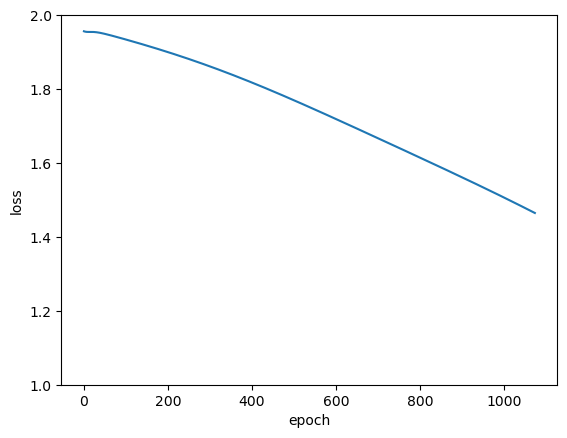

In [68]:
plt.plot(lossArray)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.ylim(1,2)
plt.show()

In [ ]:
print("\n예측 결과:")
y1 = np.dot(X, u) + u0
h = sigmoid(y1)
y2 = np.dot(h, v) + v0
z_pred = sigmoid(y2)
print(z_pred)
print(z_pred > 0.5)
print('error = ', np.sum(np.abs(z_pred-z))/len(z))

## 2 Hidden layers

In [185]:
inputs, hiddens1, hiddens2, outputs = 2, 3, 3, 1
W1 = np.random.randn(inputs, hiddens1)
W2 = np.random.randn(hiddens1, hiddens2)
W3 = np.random.randn(hiddens2, outputs)
b1 = np.zeros(hiddens1)
b2 = np.zeros(hiddens2)
b3 = np.zeros(outputs)

In [186]:
def prediction(X, W1, W2, W3, b1, b2, b3):
    layer0 = X
    y1 = np.dot(layer0, W1) + b1
    layer1 = sigmoid(y1)
    y2 = np.dot(layer1, W2) + b2
    layer2 = sigmoid(y2)
    y3 = np.dot(layer2, W3) + b3
    layer3 = sigmoid(y3)
    return layer0, layer1, layer2, layer3

In [187]:
def fit2(X, W1, W2, W3, b1, b2, b3, z, it_max=10000):
    lossArray = []     ###################
    learning_rate = 1.5
    for epoch in range(it_max):
        # prediction
        layer0, layer1, layer2, layer3 = prediction(X, W1, W2, W3, b1, b2, b3)
        z_3_hat = layer3
        
        # check break condition 
        decision = z_3_hat >= 0.5
        error = np.sum(np.abs(decision-z))
        lossArray.append(np.sum(np.abs(z_3_hat-z)))  ###################
        #print(epoch, error, loss, z_3_hat.T)
        if error == 0:
            print("break condition", epoch)
            break
        
        # Backpropagation
        layer3_error = layer3 - z
        layer3_delta = layer3_error * sigmoid_derivative(layer3)
        dW3 = np.dot(layer2.T, layer3_delta) / len(layer3_delta)
        db3 = np.sum(layer3_delta, axis=0) / len(layer3_delta)
        
        layer2_error = np.dot(layer3_delta, W3.T)
        layer2_delta = layer2_error * sigmoid_derivative(layer2)
        dW2 = np.dot(layer1.T, layer2_delta) / len(layer2_delta)
        db2 = np.sum(layer2_delta, axis=0) / len(layer2_delta)
        
        layer1_error = np.dot(layer2_delta, W2.T)
        layer1_delta = layer1_error * sigmoid_derivative(layer1)
        dW1 = np.dot(layer0.T, layer1_delta) / len(layer1_delta)
        db1 = np.sum(layer1_delta, axis=0) / len(layer1_delta)
        
        # Update
        W3 -= learning_rate * dW3
        b3 -= learning_rate * db3
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1   

    return W1, W2, W3, b1, b2, b3, np.array(lossArray)

291 2 [[0.48359509 0.51034778 0.4968852  0.51500385]]
292 2 [[0.48354856 0.51036805 0.49689817 0.51503839]]
293 2 [[0.48350178 0.51038842 0.49691121 0.51507309]]
294 2 [[0.48345476 0.51040888 0.49692431 0.51510793]]
295 2 [[0.48340749 0.51042944 0.49693748 0.51514293]]
296 2 [[0.48335997 0.51045011 0.49695071 0.51517809]]
297 2 [[0.48331221 0.51047087 0.49696401 0.5152134 ]]
298 2 [[0.4832642  0.51049173 0.49697737 0.51524887]]
299 2 [[0.48321594 0.5105127  0.4969908  0.51528449]]
300 2 [[0.48316742 0.51053377 0.49700429 0.51532027]]
301 2 [[0.48311865 0.51055494 0.49701786 0.51535622]]
302 2 [[0.48306963 0.51057621 0.49703149 0.51539232]]
303 2 [[0.48302035 0.51059759 0.49704518 0.51542858]]
304 2 [[0.48297081 0.51061908 0.49705895 0.51546501]]
305 2 [[0.48292101 0.51064066 0.49707279 0.51550159]]
306 2 [[0.48287094 0.51066236 0.49708669 0.51553834]]
307 2 [[0.48282061 0.51068416 0.49710067 0.51557526]]
308 2 [[0.48277002 0.51070607 0.49711472 0.51561234]]
309 2 [[0.48271916 0.5107280

516 1 [[0.4623637  0.51923815 0.50310471 0.5293175 ]]
517 1 [[0.46218685 0.51931117 0.50316097 0.52943039]]
518 1 [[0.46200879 0.51938468 0.50321771 0.52954398]]
519 1 [[0.46182951 0.5194587  0.50327491 0.52965829]]
520 1 [[0.46164901 0.51953322 0.50333259 0.52977333]]
521 1 [[0.46146727 0.51960826 0.50339076 0.52988909]]
522 1 [[0.46128429 0.51968381 0.50344941 0.53000559]]
523 1 [[0.46110005 0.51975988 0.50350855 0.53012283]]
524 1 [[0.46091455 0.51983647 0.50356819 0.53024081]]
525 1 [[0.46072778 0.51991359 0.50362833 0.53035955]]
526 1 [[0.46053972 0.51999125 0.50368897 0.53047904]]
527 1 [[0.46035036 0.52006944 0.50375013 0.53059929]]
528 1 [[0.46015971 0.52014817 0.5038118  0.53072031]]
529 1 [[0.45996773 0.52022745 0.503874   0.53084211]]
530 1 [[0.45977444 0.52030728 0.50393672 0.53096468]]
531 1 [[0.45957981 0.52038766 0.50399998 0.53108804]]
532 1 [[0.45938383 0.5204686  0.50406377 0.53121219]]
533 1 [[0.4591865  0.5205501  0.50412811 0.53133714]]
534 1 [[0.4589878  0.5206321

769 1 [[0.34931093 0.5678048  0.55174527 0.59504061]]
770 1 [[0.3485326  0.56814865 0.55213463 0.5954482 ]]
771 1 [[0.34775262 0.56849323 0.55252515 0.59585591]]
772 1 [[0.34697103 0.56883853 0.55291679 0.5962637 ]]
773 1 [[0.34618786 0.56918451 0.55330953 0.59667155]]
774 1 [[0.34540316 0.56953117 0.55370336 0.59707944]]
775 1 [[0.34461694 0.56987847 0.55409824 0.59748733]]
776 1 [[0.34382927 0.57022641 0.55449415 0.5978952 ]]
777 1 [[0.34304017 0.57057496 0.55489106 0.59830301]]
778 1 [[0.34224968 0.57092409 0.55528896 0.59871075]]
779 1 [[0.34145785 0.5712738  0.55568781 0.59911839]]
780 1 [[0.3406647  0.57162405 0.55608758 0.59952589]]
781 1 [[0.33987029 0.57197483 0.55648826 0.59993323]]
782 1 [[0.33907464 0.57232612 0.55688982 0.60034038]]
783 1 [[0.33827781 0.57267788 0.55729223 0.60074732]]
784 1 [[0.33747982 0.57303012 0.55769546 0.60115401]]
785 1 [[0.33668072 0.57338279 0.55809948 0.60156044]]
786 1 [[0.33588055 0.57373588 0.55850428 0.60196656]]
787 1 [[0.33507935 0.5740893

1168 1 [[0.14134984 0.6441208  0.64814995 0.65814887]]
1169 1 [[0.14116118 0.6441431  0.64822024 0.65809106]]
1170 1 [[0.14097353 0.64416492 0.64829021 0.65803244]]
1171 1 [[0.1407869  0.64418627 0.64835988 0.657973  ]]
1172 1 [[0.14060128 0.64420715 0.64842924 0.65791275]]
1173 1 [[0.14041667 0.64422756 0.64849829 0.65785168]]
1174 1 [[0.14023306 0.64424751 0.64856705 0.65778978]]
1175 1 [[0.14005046 0.64426699 0.64863551 0.65772706]]
1176 1 [[0.13986885 0.644286   0.64870367 0.65766351]]
1177 1 [[0.13968824 0.64430456 0.64877155 0.65759913]]
1178 1 [[0.13950862 0.64432265 0.64883914 0.65753391]]
1179 1 [[0.13932999 0.64434028 0.64890646 0.65746786]]
1180 1 [[0.13915235 0.64435745 0.64897349 0.65740096]]
1181 1 [[0.1389757  0.64437416 0.64904025 0.65733322]]
1182 1 [[0.13880002 0.64439041 0.64910674 0.65726463]]
1183 1 [[0.13862533 0.6444062  0.64917296 0.65719519]]
1184 1 [[0.13845161 0.64442154 0.64923892 0.6571249 ]]
1185 1 [[0.13827887 0.64443643 0.64930462 0.65705374]]
1186 1 [[0

In [188]:
it_max=10000
W1, W2, W3, b1, b2, b3, lossArray = fit2(X, W1, W2, W3, b1, b2, b3, z, it_max)

break condition 1150


In [189]:
lossArray.shape

(1151,)

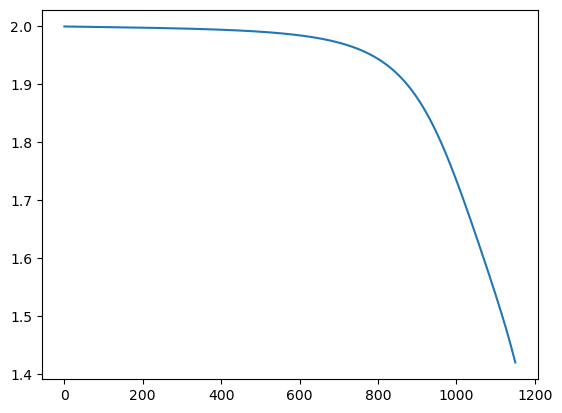

In [190]:
plt.plot(lossArray)
plt.show()